### 서울시 유가 정보 분석

In [1]:
import pandas as pd

from glob import glob # file name 합치기(데이터와는 아무 상관없음)

In [2]:
station_files = glob('../Data/oil/*.xls')
station_files

['../Data/oil/지역_위치별(주유소) (9).xls',
 '../Data/oil/지역_위치별(주유소) (12).xls',
 '../Data/oil/지역_위치별(주유소) (5).xls',
 '../Data/oil/지역_위치별(주유소) (24).xls',
 '../Data/oil/지역_위치별(주유소) (4).xls',
 '../Data/oil/지역_위치별(주유소) (13).xls',
 '../Data/oil/지역_위치별(주유소) (8).xls',
 '../Data/oil/지역_위치별(주유소) (3).xls',
 '../Data/oil/지역_위치별(주유소) (18).xls',
 '../Data/oil/지역_위치별(주유소) (22).xls',
 '../Data/oil/지역_위치별(주유소) (14).xls',
 '../Data/oil/지역_위치별(주유소) (15).xls',
 '../Data/oil/지역_위치별(주유소) (23).xls',
 '../Data/oil/지역_위치별(주유소) (19).xls',
 '../Data/oil/지역_위치별(주유소) (2).xls',
 '../Data/oil/지역_위치별(주유소) (20).xls',
 '../Data/oil/지역_위치별(주유소) (1).xls',
 '../Data/oil/지역_위치별(주유소) (16).xls',
 '../Data/oil/지역_위치별(주유소) (17).xls',
 '../Data/oil/지역_위치별(주유소) (21).xls',
 '../Data/oil/지역_위치별(주유소) (10).xls',
 '../Data/oil/지역_

In [3]:
!pip install xlrd

In [4]:
tmp_raw = []

for file_name in station_files:
  tmp = pd.read_excel(file_name, header=2)
  tmp_raw.append(tmp)


station_raw = pd.concat(tmp_raw) # list를 합치면 dp이 된다.

In [5]:
len(station_raw)

418

In [6]:
station_raw.head()

,지역,상호,주소,상표,전화번호,셀프여부,고급휘발유,휘발유,경유,실내등유
0,서울특별시,이케이에너지 주식회사,서울 도봉구 도봉로 941 (도봉동),HD현대오일뱅크,02-3494-3641,Y,-,1609,1479,-
1,서울특별시,요한주유소,서울 도봉구 마들로 776,HD현대오일뱅크,02-955-8669,Y,-,1609,1479,-
2,서울특별시,(주)자연에너지 햇살주유소,서울 도봉구 방학로 142 (방학동),HD현대오일뱅크,02-954-4555,Y,1830,1609,1479,-
3,서울특별시,삼미북부셀프주유소,서울 도봉구 도봉로 437 (쌍문동),SK에너지,02-992-5561,Y,-,1609,1479,-
4,서울특별시,쌍문으뜸주유소,서울 도봉구 노해로 161 (쌍문동),HD현대오일뱅크,02-998-9704,Y,1855,1609,1479,-


In [7]:
station_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 8
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      418 non-null    object
 1   상호      418 non-null    object
 2   주소      418 non-null    object
 3   상표      418 non-null    object
 4   전화번호    418 non-null    object
 5   셀프여부    418 non-null    object
 6   고급휘발유   418 non-null    object
 7   휘발유     418 non-null    int64 
 8   경유      418 non-null    int64 
 9   실내등유    418 non-null    object
dtypes: int64(2), object(8)
memory usage: 35.9+ KB


In [8]:
# 필요항목 발췌

stations = pd.DataFrame(
  {
    'Oil_store' : station_raw['상호'],
    '주소' : station_raw['주소'],
    '가격' : station_raw['휘발유'],
    '셀프' : station_raw['셀프여부'],
    '상표' : station_raw['상표']
  }
)

stations.head()

,Oil_store,주소,가격,셀프,상표
0,이케이에너지 주식회사,서울 도봉구 도봉로 941 (도봉동),1609,Y,HD현대오일뱅크
1,요한주유소,서울 도봉구 마들로 776,1609,Y,HD현대오일뱅크
2,(주)자연에너지 햇살주유소,서울 도봉구 방학로 142 (방학동),1609,Y,HD현대오일뱅크
3,삼미북부셀프주유소,서울 도봉구 도봉로 437 (쌍문동),1609,Y,SK에너지
4,쌍문으뜸주유소,서울 도봉구 노해로 161 (쌍문동),1609,Y,HD현대오일뱅크


In [9]:
# 주소 컬럼에 광역시명만 리스트로 정리하기

set([region.split()[0] for region in stations.주소])
# k:v가 가 없으면 set이다.

{'서울', '서울시', '서울특별시'}

In [10]:
# 서울특별시 -> 서울, 서울시 -> 서울

stations.주소 = stations.주소.str.replace('서울특별시','서울')
stations.주소 = stations.주소.str.replace('서울시','서울') # replace는 str밖에 안된다.

stations.head()

,Oil_store,주소,가격,셀프,상표
0,이케이에너지 주식회사,서울 도봉구 도봉로 941 (도봉동),1609,Y,HD현대오일뱅크
1,요한주유소,서울 도봉구 마들로 776,1609,Y,HD현대오일뱅크
2,(주)자연에너지 햇살주유소,서울 도봉구 방학로 142 (방학동),1609,Y,HD현대오일뱅크
3,삼미북부셀프주유소,서울 도봉구 도봉로 437 (쌍문동),1609,Y,SK에너지
4,쌍문으뜸주유소,서울 도봉구 노해로 161 (쌍문동),1609,Y,HD현대오일뱅크


In [11]:
# 주요소별 자치구 항목 추가 ( 컬럼이름 구 )
stations['구'] = \
[region.split()[1] for region in stations.주소]

In [12]:
stations.head()

,Oil_store,주소,가격,셀프,상표,구
0,이케이에너지 주식회사,서울 도봉구 도봉로 941 (도봉동),1609,Y,HD현대오일뱅크,도봉구
1,요한주유소,서울 도봉구 마들로 776,1609,Y,HD현대오일뱅크,도봉구
2,(주)자연에너지 햇살주유소,서울 도봉구 방학로 142 (방학동),1609,Y,HD현대오일뱅크,도봉구
3,삼미북부셀프주유소,서울 도봉구 도봉로 437 (쌍문동),1609,Y,SK에너지,도봉구
4,쌍문으뜸주유소,서울 도봉구 노해로 161 (쌍문동),1609,Y,HD현대오일뱅크,도봉구


In [13]:
# 25개의 파일을 합쳐서 만든 데이터 프레임

stations[stations.index == 8]

,Oil_store,주소,가격,셀프,상표,구
8,극동유화(주) 대안주유소,서울 도봉구 마들로 574 (창동),1625,Y,S-OIL,도봉구
8,(주)만성상사 대흥주유소,서울 마포구 대흥로 61 (대흥동),1698,N,SK에너지,마포구
8,HD현대오일뱅크㈜직영 장호셀프주유소,서울 광진구 자양로 37,1629,Y,HD현대오일뱅크,광진구
8,용마로주유소,서울 중랑구 용마산로 309 (면목동),1658,Y,SK에너지,중랑구
8,SK에너지(주)직영 신봉천주유소,서울 관악구 남부순환로 1880 (봉천동),1685,N,SK에너지,관악구
8,연희주유소,서울 서대문구 연희로 129 (연희동 89-7번지),1695,N,SK에너지,서대문구
8,상계동주유소,서울 노원구 노원로26길 191 (상계동),1695,N,HD현대오일뱅크,노원구
8,뉴신정주유소,서울 강서구 곰달래로 207,1613,N,알뜰주유소,강서구
8,삼미상사(주)신월IC셀프주유소,서울 양천구 중앙로 331 (신월동),1609,Y,SK에너지,양천구
8,양재최고주유소,서울 서초구 매헌로 72 (양재동),1654,N,S-OIL,서초구


In [14]:
# index 재구성

stations.reset_index(
  drop=True,
  inplace=True
)

stations[stations.index == 8]

,Oil_store,주소,가격,셀프,상표,구
8,극동유화(주) 대안주유소,서울 도봉구 마들로 574 (창동),1625,Y,S-OIL,도봉구


In [15]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

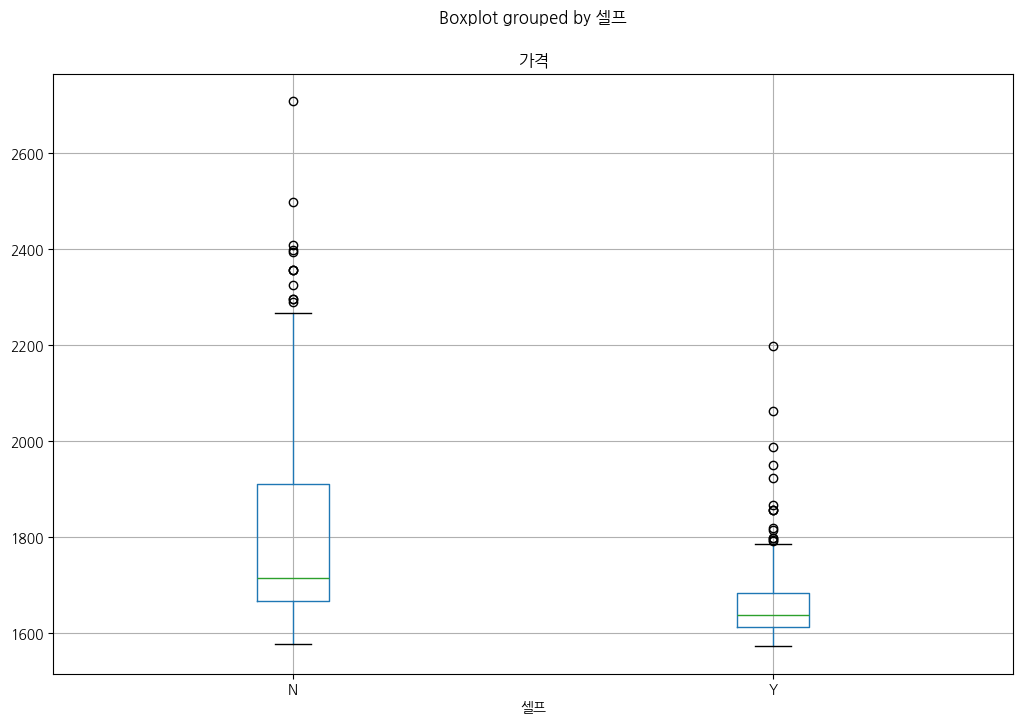

In [16]:
# 셀프주유소가 더 싼가?
# boxplot
stations.boxplot(
  column='가격',
  by='셀프',
  figsize=(12,8)
)

plt.show()

In [17]:
import seaborn as sns

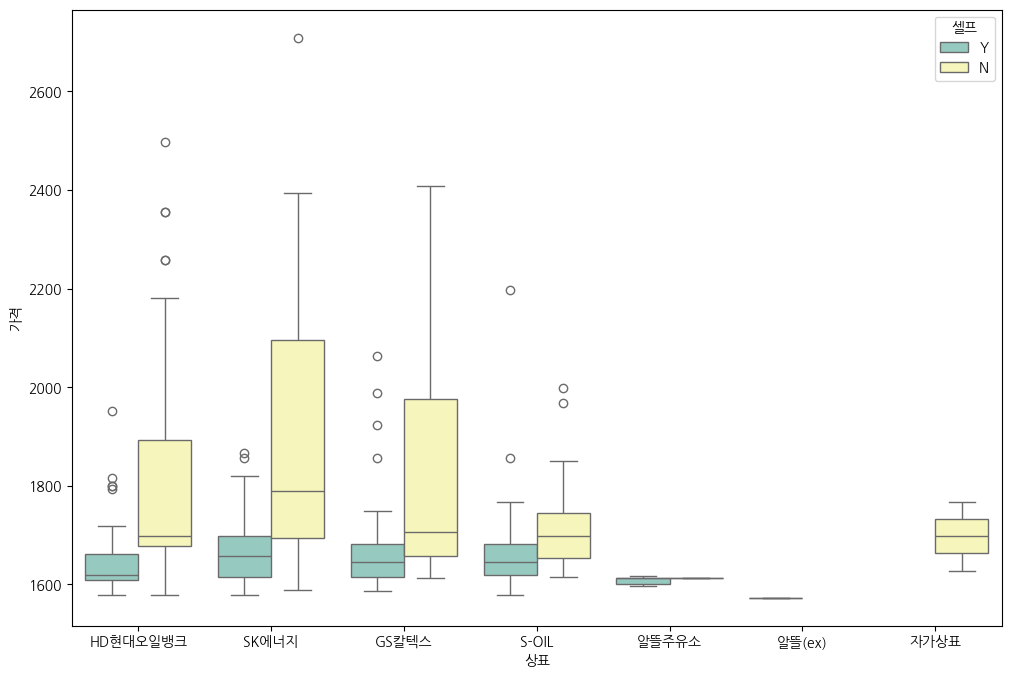

In [18]:
# 상표, 가격, 셀프를 boxplot으로 그리기

plt.figure(figsize=(12,8))
sns.boxplot(
  x = '상표',
  y = '가격',
  hue = '셀프',
  data = stations,
  palette='Set3'
)

plt.show()

In [19]:
import warnings
warnings.filterwarnings('ignore')

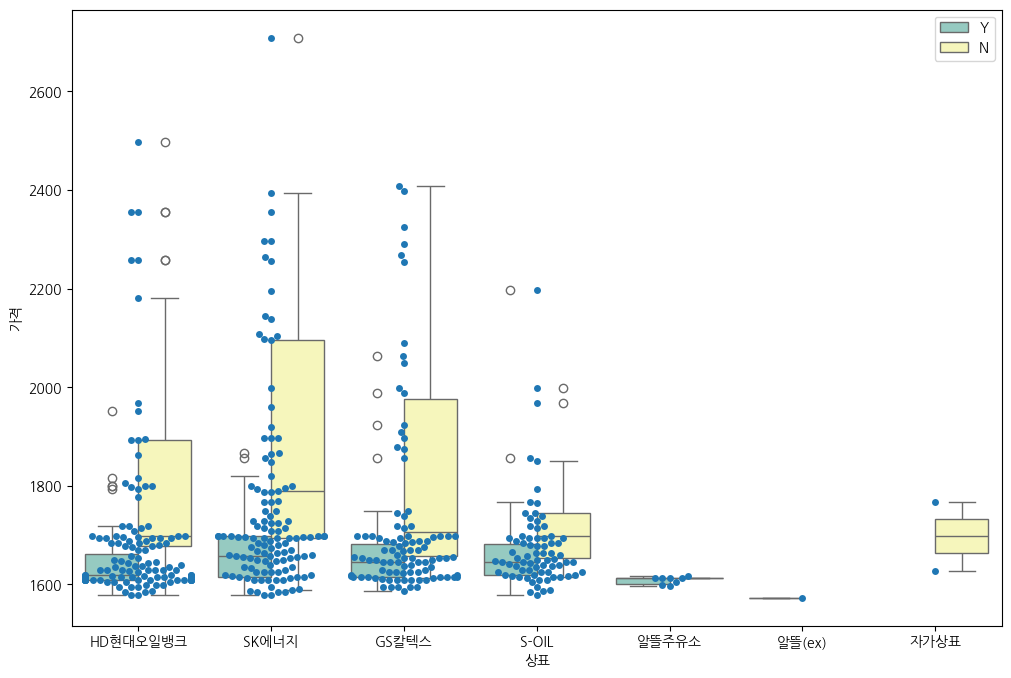

In [20]:
# 상표, 가격, 셀프를 boxplot으로 그리기

plt.figure(figsize=(12,8))
sns.boxplot(
  x = '상표',
  y = '가격',
  hue = '셀프',
  data = stations,
  palette='Set3'
)




sns.swarmplot(
  x='상표',
  y='가격',
  data=stations



)
plt.show()

In [21]:
# 가격이 높은 순으로 정렬(top10)



stations.sort_values(
  by='가격',
  ascending=False
).head(10)



,Oil_store,주소,가격,셀프,상표,구
212,서남주유소,서울 중구 통일로 30,2709,N,SK에너지,중구
379,(주)제이제이네트웍스 제이제이주유소,서울 강남구 언주로 716,2498,N,HD현대오일뱅크,강남구
211,필동주유소,서울 중구 퇴계로 196,2409,N,GS칼텍스,중구
378,(주)소모 쎈트럴주유소,서울 강남구 삼성로 335,2398,N,GS칼텍스,강남구
377,SK논현주유소,서울 강남구 논현로 747 (논현동),2395,N,SK에너지,강남구
257,동자동주유소,서울 용산구 한강대로104길 6 (동자동),2356,N,SK에너지,용산구
258,HD현대오일뱅크㈜직영 갈월동주유소,서울 용산구 한강대로 322 (남영동),2356,N,HD현대오일뱅크,용산구
259,HD현대오일뱅크(주)직영 소월길주유소,서울 용산구 소월로 66 (후암동),2356,N,HD현대오일뱅크,용산구
156,(주)대양씨앤씨 사직주유소,서울 종로구 사직로 65,2325,N,GS칼텍스,종로구
255,한남지점,서울 용산구 한남대로21길 4 (한남동),2297,N,SK에너지,용산구


In [22]:
# 가격이 낮은 순으로 정렬(top10)



stations.sort_values(
  by='가격',
).head(10)

,Oil_store,주소,가격,셀프,상표,구
157,㈜에이치앤디이 만남의광장주유소,서울 서초구 양재대로12길 73-71,1573,Y,알뜰(ex),서초구
327,㈜한화미 구파발주유소,서울 은평구 통일로 1031,1578,Y,S-OIL,은평구
326,박석고개2주유소,서울 은평구 통일로 924,1578,Y,SK에너지,은평구
325,(주)디오티디 은평유니콘주유소,서울 은평구 통일로 1151,1578,N,HD현대오일뱅크,은평구
324,박석고개주유소,서울 은평구 통일로 945 (갈현동),1578,Y,SK에너지,은평구
323,불광주유소,서울 은평구 연서로 314,1578,Y,HD현대오일뱅크,은평구
92,(주)타이거오일 방화주유소,서울 강서구 방화동로 58-2,1584,Y,SK에너지,강서구
328,타이거주유소,서울 은평구 수색로 188 (증산동),1584,Y,SK에너지,은평구
126,양천구주유소,서울 양천구 국회대로 275,1584,Y,HD현대오일뱅크,양천구
125,(주)타이거오일 신정주유소,서울 양천구 중앙로 226 (신정동),1584,Y,SK에너지,양천구


In [23]:
# 가장 비싼 가격과 싼 가격의 차이
# stations.sort_values(by='가격',ascending=False).head(1).가격.values - stations.sort_values(by='가격').head(1).가격.values

stations.가격.max() - stations.가격.min()



1136

In [24]:
# 구별 가격 평균


gu_data = \
stations.pivot_table(
  ['가격'],
  index=['구'],
  aggfunc='mean'
)
gu_data.head()

,가격
구,
강남구,1886.107143
강동구,1726.250000
강북구,1630.333333
강서구,1662.303030
관악구,1694.642857


In [25]:
# 구별 가격 평균 높은순

gu_data.sort_values(
  by='가격',
  ascending=False
).head(10)

,가격
구,
용산구,2178.333333
중구,1984.300000
강남구,1886.107143
종로구,1879.875000
영등포구,1731.692308
강동구,1726.250000
성동구,1724.000000
서초구,1703.766667
구로구,1700.833333


# 지도표시

In [26]:
import json
import folium

In [27]:
geo_path = "../Data/skorea_municipalities_geo_simple.json"
geo_str = json.load(open(geo_path, encoding='utf-8'))

seoul = folium.Map(
  location=[37.5502, 126.982],
  zoom_start=10
)

folium.Choropleth(
  geo_data=geo_str,
  data=gu_data,
  columns=[gu_data.index, '가격'],
  fill_color='PuRd',
  key_on='feature.properties.name'
).add_to(seoul)

seoul

In [28]:
# 가격이 제일 비싼 Top 10 구성

oil_price_top10 = stations.sort_values(
  by='가격',
  ascending=False
).head(10)
oil_price_top10


,Oil_store,주소,가격,셀프,상표,구
212,서남주유소,서울 중구 통일로 30,2709,N,SK에너지,중구
379,(주)제이제이네트웍스 제이제이주유소,서울 강남구 언주로 716,2498,N,HD현대오일뱅크,강남구
211,필동주유소,서울 중구 퇴계로 196,2409,N,GS칼텍스,중구
378,(주)소모 쎈트럴주유소,서울 강남구 삼성로 335,2398,N,GS칼텍스,강남구
377,SK논현주유소,서울 강남구 논현로 747 (논현동),2395,N,SK에너지,강남구
257,동자동주유소,서울 용산구 한강대로104길 6 (동자동),2356,N,SK에너지,용산구
258,HD현대오일뱅크㈜직영 갈월동주유소,서울 용산구 한강대로 322 (남영동),2356,N,HD현대오일뱅크,용산구
259,HD현대오일뱅크(주)직영 소월길주유소,서울 용산구 소월로 66 (후암동),2356,N,HD현대오일뱅크,용산구
156,(주)대양씨앤씨 사직주유소,서울 종로구 사직로 65,2325,N,GS칼텍스,종로구
255,한남지점,서울 용산구 한남대로21길 4 (한남동),2297,N,SK에너지,용산구


In [29]:
# 가격이 제일 싼 bottom10 구성

oil_price_bottom10 = stations.sort_values(
  by='가격',
  ascending=True
).head(10)
oil_price_bottom10

,Oil_store,주소,가격,셀프,상표,구
157,㈜에이치앤디이 만남의광장주유소,서울 서초구 양재대로12길 73-71,1573,Y,알뜰(ex),서초구
327,㈜한화미 구파발주유소,서울 은평구 통일로 1031,1578,Y,S-OIL,은평구
326,박석고개2주유소,서울 은평구 통일로 924,1578,Y,SK에너지,은평구
325,(주)디오티디 은평유니콘주유소,서울 은평구 통일로 1151,1578,N,HD현대오일뱅크,은평구
324,박석고개주유소,서울 은평구 통일로 945 (갈현동),1578,Y,SK에너지,은평구
323,불광주유소,서울 은평구 연서로 314,1578,Y,HD현대오일뱅크,은평구
92,(주)타이거오일 방화주유소,서울 강서구 방화동로 58-2,1584,Y,SK에너지,강서구
328,타이거주유소,서울 은평구 수색로 188 (증산동),1584,Y,SK에너지,은평구
126,양천구주유소,서울 양천구 국회대로 275,1584,Y,HD현대오일뱅크,양천구
125,(주)타이거오일 신정주유소,서울 양천구 중앙로 226 (신정동),1584,Y,SK에너지,양천구


---
#### Top10의 위경도 찾기
: openStreet Map 사용

In [30]:
# !pip install geopy

In [32]:
from geopy.geocoders import Nominatim

In [33]:
def get_lat_lng(address):
  try:
    geolocoder=Nominatim(user_agent='South Korea', timeout=None)
    geo = geolocoder.geocode(address)
    lat_lng = {"lat" : str(geo.latitude), "lng" : str(geo.longitude)}
  except:
    lat_lng = {"lat" : str(0), "lng" : str(0)}
  finally:
    return lat_lng

In [35]:
# Test

print(get_lat_lng('경기 성남시 분당구 판교역로 136'))
print(get_lat_lng('경기 성북시 분당구 판교역로 136'))

{'lat': '37.3836033', 'lng': '127.1118697'}
{'lat': '0', 'lng': '0'}


In [73]:
# Top10의 위도 경도 찾기
station_lat = []
station_lng = []

for name in oil_price_top10['주소']:
  print(name)
  response = get_lat_lng(name)
  station_lat.append(response['lat'])
  station_lng.append(response['lng'])


서울 중구 통일로 30
서울 강남구 언주로 716
서울 중구 퇴계로 196
서울 강남구 삼성로 335
서울 강남구 논현로 747 (논현동)
서울 용산구 한강대로104길 6 (동자동)
서울 용산구  한강대로 322 (남영동)
서울 용산구 소월로 66 (후암동)
서울 종로구 사직로 65
서울 용산구 한남대로21길 4 (한남동)


In [42]:
print(len(station_lat))
print(len(station_lng))

10
10


In [74]:
# 위도 경도 추가
oil_price_top10['lat'] = station_lat
oil_price_top10['lng'] = station_lng
oil_price_top10

,Oil_store,주소,가격,셀프,상표,구,lat,lng
212,서남주유소,서울 중구 통일로 30,2709,N,SK에너지,중구,37.5572783,126.9721329
379,(주)제이제이네트웍스 제이제이주유소,서울 강남구 언주로 716,2498,N,HD현대오일뱅크,강남구,37.5176821,127.0357146
211,필동주유소,서울 중구 퇴계로 196,2409,N,GS칼텍스,중구,37.5608878,126.993675
378,(주)소모 쎈트럴주유소,서울 강남구 삼성로 335,2398,N,GS칼텍스,강남구,37.5028366,127.0588629
377,SK논현주유소,서울 강남구 논현로 747 (논현동),2395,N,SK에너지,강남구,0,0
257,동자동주유소,서울 용산구 한강대로104길 6 (동자동),2356,N,SK에너지,용산구,0,0
258,HD현대오일뱅크㈜직영 갈월동주유소,서울 용산구 한강대로 322 (남영동),2356,N,HD현대오일뱅크,용산구,37.5545547,126.9707793
259,HD현대오일뱅크(주)직영 소월길주유소,서울 용산구 소월로 66 (후암동),2356,N,HD현대오일뱅크,용산구,0,0
156,(주)대양씨앤씨 사직주유소,서울 종로구 사직로 65,2325,N,GS칼텍스,종로구,37.5745113,126.9666378
255,한남지점,서울 용산구 한남대로21길 4 (한남동),2297,N,SK에너지,용산구,0,0


#### Kakao API 를 사용

- kakao api(https://developers.kakao.com)를 이용하여 Rest API Key 발급
- 애플리케이션 추가하기
- 앱권한 설정
- 앱설정 -> 앱키 -> RestAPI key 복사
426b61a8de0023b7b9d1bc97d0ca6302

In [54]:
api_key='eb71a887d20a94f7c693311e95bf407b'

In [55]:
import requests

In [75]:
def kakao_lat_lng(address):
    url = f'https://dapi.kakao.com/v2/local/search/address.json?query={address}'
    headers = {"Authorization" : "KakaoAK " + api_key}
    try:
        result = json.loads(str(requests.get(url, headers=headers).text))
        mathLoc = result['documents'][0]['address']
        result = float(mathLoc['x']), float(mathLoc['y'])
    except:
        result = 0, 0
    finally:
        return result

In [57]:
kakao_lat_lng("경기 성남시 분당구 판교역로 136")

(127.110430292919, 37.3925072208217)

> 위도와 경도가 바꾸어 나온다.

In [76]:
station_lat = []
station_lng = []

for name in zip(oil_price_top10['주소'], oil_price_top10['lat'],oil_price_top10['lng']):
  if name[1] == '0':
    result = kakao_lat_lng(name[0])
    station_lat.append(result[1])
    station_lng.append(result[0])
  else:
    station_lat.append(name[1])
    station_lng.append(name[2])

In [77]:
oil_price_top10['lat'] = station_lat
oil_price_top10['lng'] = station_lng
oil_price_top10


,Oil_store,주소,가격,셀프,상표,구,lat,lng
212,서남주유소,서울 중구 통일로 30,2709,N,SK에너지,중구,37.5572783,126.9721329
379,(주)제이제이네트웍스 제이제이주유소,서울 강남구 언주로 716,2498,N,HD현대오일뱅크,강남구,37.5176821,127.0357146
211,필동주유소,서울 중구 퇴계로 196,2409,N,GS칼텍스,중구,37.5608878,126.993675
378,(주)소모 쎈트럴주유소,서울 강남구 삼성로 335,2398,N,GS칼텍스,강남구,37.5028366,127.0588629
377,SK논현주유소,서울 강남구 논현로 747 (논현동),2395,N,SK에너지,강남구,37.518533,127.028244
257,동자동주유소,서울 용산구 한강대로104길 6 (동자동),2356,N,SK에너지,용산구,37.550201,126.972418
258,HD현대오일뱅크㈜직영 갈월동주유소,서울 용산구 한강대로 322 (남영동),2356,N,HD현대오일뱅크,용산구,37.5545547,126.9707793
259,HD현대오일뱅크(주)직영 소월길주유소,서울 용산구 소월로 66 (후암동),2356,N,HD현대오일뱅크,용산구,37.554409,126.977735
156,(주)대양씨앤씨 사직주유소,서울 종로구 사직로 65,2325,N,GS칼텍스,종로구,37.5745113,126.9666378
255,한남지점,서울 용산구 한남대로21길 4 (한남동),2297,N,SK에너지,용산구,37.534771,127.00611


In [78]:
# bottom10의 위도 경도 찾기
station_lat = []
station_lng = []

for name in oil_price_bottom10['주소']:
  print(name)
  response = get_lat_lng(name)
  station_lat.append(response['lat'])
  station_lng.append(response['lng'])

서울 서초구 양재대로12길 73-71
서울 은평구 통일로 1031
서울 은평구 통일로 924
서울 은평구 통일로 1151
서울 은평구 통일로 945 (갈현동)
서울 은평구 연서로 314
서울 강서구 방화동로 58-2
서울 은평구 수색로 188 (증산동)
서울 양천구 국회대로 275
서울 양천구 중앙로 226 (신정동)


In [79]:
# 위도 경도 추가
oil_price_bottom10['lat'] = station_lat
oil_price_bottom10['lng'] = station_lng
oil_price_bottom10

,Oil_store,주소,가격,셀프,상표,구,lat,lng
157,㈜에이치앤디이 만남의광장주유소,서울 서초구 양재대로12길 73-71,1573,Y,알뜰(ex),서초구,37.460084,127.042169
327,㈜한화미 구파발주유소,서울 은평구 통일로 1031,1578,Y,S-OIL,은평구,37.6346863,126.9165857
326,박석고개2주유소,서울 은평구 통일로 924,1578,Y,SK에너지,은평구,37.619894,126.920001
325,(주)디오티디 은평유니콘주유소,서울 은평구 통일로 1151,1578,N,HD현대오일뱅크,은평구,37.6439543,126.9124378
324,박석고개주유소,서울 은평구 통일로 945 (갈현동),1578,Y,SK에너지,은평구,0,0
323,불광주유소,서울 은평구 연서로 314,1578,Y,HD현대오일뱅크,은평구,37.6024408,126.9158238
92,(주)타이거오일 방화주유소,서울 강서구 방화동로 58-2,1584,Y,SK에너지,강서구,37.5632988,126.8101329
328,타이거주유소,서울 은평구 수색로 188 (증산동),1584,Y,SK에너지,은평구,0,0
126,양천구주유소,서울 양천구 국회대로 275,1584,Y,HD현대오일뱅크,양천구,37.530301,126.865419
125,(주)타이거오일 신정주유소,서울 양천구 중앙로 226 (신정동),1584,Y,SK에너지,양천구,0,0


In [80]:
station_lat = []
station_lng = []

for name in zip(oil_price_bottom10['주소'], oil_price_bottom10['lat'],oil_price_bottom10['lng']):
  if name[1] == '0':
    result = kakao_lat_lng(name[0])
    station_lat.append(result[1])
    station_lng.append(result[0])
  else:
    station_lat.append(name[1])
    station_lng.append(name[2])

In [81]:
oil_price_bottom10['lat'] = station_lat
oil_price_bottom10['lng'] = station_lng
oil_price_bottom10


,Oil_store,주소,가격,셀프,상표,구,lat,lng
157,㈜에이치앤디이 만남의광장주유소,서울 서초구 양재대로12길 73-71,1573,Y,알뜰(ex),서초구,37.460084,127.042169
327,㈜한화미 구파발주유소,서울 은평구 통일로 1031,1578,Y,S-OIL,은평구,37.6346863,126.9165857
326,박석고개2주유소,서울 은평구 통일로 924,1578,Y,SK에너지,은평구,37.619894,126.920001
325,(주)디오티디 은평유니콘주유소,서울 은평구 통일로 1151,1578,N,HD현대오일뱅크,은평구,37.6439543,126.9124378
324,박석고개주유소,서울 은평구 통일로 945 (갈현동),1578,Y,SK에너지,은평구,37.627285,126.919398
323,불광주유소,서울 은평구 연서로 314,1578,Y,HD현대오일뱅크,은평구,37.6024408,126.9158238
92,(주)타이거오일 방화주유소,서울 강서구 방화동로 58-2,1584,Y,SK에너지,강서구,37.5632988,126.8101329
328,타이거주유소,서울 은평구 수색로 188 (증산동),1584,Y,SK에너지,은평구,37.578552,126.902034
126,양천구주유소,서울 양천구 국회대로 275,1584,Y,HD현대오일뱅크,양천구,37.530301,126.865419
125,(주)타이거오일 신정주유소,서울 양천구 중앙로 226 (신정동),1584,Y,SK에너지,양천구,37.516747,126.854738


In [86]:
# 서울 지도에 위치 표시하기
seoul_map = folium.Map(
  location=[37.55, 126.98],
  zoom_start=12
)

# 위치 정보를 Marker로 표시
for Oil_store, lat, lng in zip(oil_price_top10.Oil_store, oil_price_top10.lat, oil_price_top10.lng):
  popup = folium.Popup(Oil_store, max_width=200)
  folium.Marker(
    [lat,lng],
    popup=popup,
    icon=folium.Icon(color='red')
  ).add_to(seoul_map)



for Oil_store, lat, lng in zip(oil_price_bottom10.Oil_store, oil_price_bottom10.lat, oil_price_bottom10.lng):
  popup = folium.Popup(Oil_store, max_width=200)
  folium.Marker(
    [lat,lng],
    popup=popup,
    icon=folium.Icon(color='blue')
  ).add_to(seoul_map)

seoul_map